# Lab 05 — Applying Embeddings to Text Classification

**NLP Applications Laboratory | KLEF | 2026**

*From vectors of words to decisions about documents — how the embeddings we built become the foundation of a real machine learning system.*

## Objective

Across Labs 02, 03, and 04 we built four families of word vectors:

- **One-hot** — every word is its own island
- **Bag of Words / TF-IDF** — sentences as counts, informative words weighted higher
- **Co-occurrence matrix** — words known by the company they keep
- **Word2Vec (from scratch)** — dense vectors learned by a neural network

Every one of those was measured by **cosine similarity between word pairs**. That is a laboratory metric — useful for inspection, but not the metric anyone gets paid for in industry.

**Industry pays for accuracy on a real task.**

In this lab we finally use our embeddings for one. We build a **text classifier** — a model that reads a document and predicts what category it belongs to — using 20 Newsgroups, a real-world dataset of Usenet posts.

By the end you will be able to:

1. Load and prepare the **20 Newsgroups** dataset (4 categories).
2. Build a **TF-IDF + Logistic Regression** baseline classifier.
3. Use **pretrained Word2Vec** (Google News, 300d) to represent documents as averaged word vectors, and classify them.
4. Use **pretrained GloVe** (6B, 100d) — Word2Vec's mathematical rival — for the same task.
5. Use **Sentence-BERT** — the modern transformer-based sentence embedder — for the same task.
6. Use **`nomic-embed-text`** running locally on your machine via Ollama — the same infrastructure that powers our `chat()` widget.
7. Compare all five methods on identical test data and understand *why* each performed as it did.

The core question of this lab:

> *"When you plug embeddings into a real classifier and let it decide category labels on unseen text, which embedding gives the best accuracy — and why?"*

You will not just have opinions. You will have numbers.

## What you will learn before we start

This lab has **ten phases**, moving from a Word2Vec warm-up through five real classifiers to a comparison table that answers the lab's central question.

### Phase 1 — Warm-up: Pretrained Word2Vec and analogies

We finally do the thing we skipped at the end of Lab 04: load Google's pretrained Word2Vec (trained on 100 billion words) and demonstrate the famous:


If you were skeptical that embeddings capture real semantic structure, this is where that skepticism gets resolved.

### Phase 2 — GloVe: A different path to the same destination

Stanford's answer to Word2Vec (2014). Where Word2Vec learns by predicting neighbors, GloVe learns by factorizing the **co-occurrence matrix from Lab 03**. Different math, similar result. Lab 03's co-occurrence matrix wasn't a dead end — it was foundational.

### Phase 3 — Meet GloVe in code

Load pretrained GloVe (6B tokens, 100d vectors). Compare its analogies against Word2Vec's on the same word pairs.

### Phase 4 — The real dataset: 20 Newsgroups

Load 4 well-separated categories:

- `sci.med` — medical discussions
- `sci.space` — space and astronomy
- `rec.autos` — cars and driving
- `talk.politics.guns` — political debate

Inspect the data: how many training documents? How many test documents? What does a real post look like?

### Phase 5 — Baseline: TF-IDF + Logistic Regression

The classical NLP baseline. TF-IDF vectorize each document, train a Logistic Regression classifier, measure accuracy on unseen test posts. This is the number to beat.

### Phase 6 — Averaged Word2Vec + Logistic Regression

Represent each document by **averaging** the Word2Vec vectors of its words. Same classifier, richer features. Compare accuracy.

### Phase 7 — Averaged GloVe + Logistic Regression

Same pipeline, GloVe vectors. Does Stanford beat Google on this task?

### Phase 8 — Sentence-BERT + Logistic Regression

Modern transformer-based embeddings. Each document becomes a single 384-dim vector (not an average of word vectors). Compare.

### Phase 9 — Local `nomic-embed-text` + Logistic Regression

The embedding model already running on your machine via Ollama — no downloads, no cloud. See how a local open-source embedder holds up.

### Phase 10 — Grand comparison and wrap-up

One table, five accuracies, one clear ranking. Discussion of why each method performed as it did — and which one you would actually deploy in production.

---

**About difficulty:** every phase in this lab is straightforward on its own. The complexity is in the **comparison**: you will need to keep track of which pipeline you are running and why. Take notes. Use `chat()` when you want to inspect a classifier's predictions or ask why an accuracy came out the way it did.

---

## Phase 1 — Warm-up: Pretrained Word2Vec

In Lab 04 we trained Word2Vec ourselves on our tiny 12-sentence corpus. The mechanism worked, but the vectors were weak — 12 sentences is not enough data for real semantic structure to emerge.

**Google's pretrained Word2Vec is different.** It was trained on ~100 billion words scraped from Google News articles. Each word is represented by a 300-dimensional vector. The model file is 1.5 GB and contains vectors for 3 million words and phrases.

You already downloaded this model during `setup_data.py`. Loading takes a few seconds — it just reads the cached file from disk.

### What we will do in this phase

1. Load the model
2. Inspect one word's vector
3. Find the nearest neighbors of a few interesting words
4. Do the famous analogy: `king − man + woman ≈ ?`

If our previous labs' embeddings were "kind of working", this phase will feel like a magic trick.

# Load pretrained Word2Vec

In [1]:
# Load Google's pretrained Word2Vec — trained on ~100 billion words
import gensim.downloader as api
print("Loading Word2Vec (Google News 300d)... this takes 10-30 seconds from cache")
w2v = api.load('word2vec-google-news-300')
print(f"Loaded. Vocabulary size: {len(w2v.key_to_index):,} words")
print(f"Vector dimension: {w2v.vector_size}")

Loading Word2Vec (Google News 300d)... this takes 10-30 seconds from cache
Loaded. Vocabulary size: 3,000,000 words
Vector dimension: 300


### Inspect one word's vector

In [2]:
# Look at the vector for a single word
king_vec = w2v['king']
print(f"Shape: {king_vec.shape}")
print(f"First 10 values: {king_vec[:10].round(3)}")
print(f"Vector norm    : {(king_vec ** 2).sum() ** 0.5:.3f}")

Shape: (300,)
First 10 values: [ 0.126  0.03   0.009  0.14  -0.026 -0.036  0.112 -0.198  0.051  0.363]
Vector norm    : 2.902


### Print vectors for several other words

In [3]:
# Inspect vectors for a few different kinds of words
for word in ['queen', 'computer', 'India', 'happiness', 'the']:
    v = w2v[word]
    print(f"{word:<12} shape={v.shape} first 5 values: {v[:5].round(3)}  norm={((v**2).sum()**0.5):.3f}")

queen        shape=(300,) first 5 values: [ 0.005 -0.144 -0.069  0.124  0.132]  norm=3.028
computer     shape=(300,) first 5 values: [ 0.107 -0.201  0.123  0.212 -0.091]  norm=2.632
India        shape=(300,) first 5 values: [-0.032  0.061  0.173  0.254 -0.197]  norm=2.676
happiness    shape=(300,) first 5 values: [ 0.271 -0.132  0.129  0.221  0.256]  norm=3.249
the          shape=(300,) first 5 values: [ 0.08   0.105  0.05   0.053 -0.067]  norm=1.072


# Full model specifications

In [4]:
# The full "spec sheet" of the Word2Vec model
import os
import gensim.downloader as api

n_words = len(w2v.key_to_index)
n_dims  = w2v.vector_size
n_params = n_words * n_dims
model_path = api.load('word2vec-google-news-300', return_path=True)
disk_size_gb = os.path.getsize(model_path) / (1024**3)

print(f"Model name         : Word2Vec Google News 300d")
print(f"Vocabulary size    : {n_words:,} words/phrases")
print(f"Vector dimension   : {n_dims}")
print(f"Total parameters   : {n_params:,}  (words × dimensions)")
print(f"Memory (float32)   : {n_params * 4 / (1024**3):.2f} GB uncompressed")
print(f"Disk size (cached) : {disk_size_gb:.2f} GB (gzip-compressed)")
print(f"Location on disk   : {model_path}")

Model name         : Word2Vec Google News 300d
Vocabulary size    : 3,000,000 words/phrases
Vector dimension   : 300
Total parameters   : 900,000,000  (words × dimensions)
Memory (float32)   : 3.35 GB uncompressed
Disk size (cached) : 1.62 GB (gzip-compressed)
Location on disk   : C:\Users\Dr.PVVK/gensim-data\word2vec-google-news-300\word2vec-google-news-300.gz


# Extra info about the model

In [5]:
# What other interesting things does the model contain?
print(f"First 10 vocabulary entries: {list(w2v.key_to_index.keys())[:10]}")
print(f"Contains 'king'    : {'king' in w2v}")
print(f"Contains 'kingdom' : {'kingdom' in w2v}")
print(f"Contains 'kng'     : {'kng' in w2v}")
print(f"Contains 'New_York': {'New_York' in w2v}")
print(f"Contains 'newyork' : {'newyork' in w2v}")

First 10 vocabulary entries: ['</s>', 'in', 'for', 'that', 'is', 'on', '##', 'The', 'with', 'said']
Contains 'king'    : True
Contains 'kingdom' : True
Contains 'kng'     : False
Contains 'New_York': True
Contains 'newyork' : True


# Nearest neighbor lookup

In [6]:
# For each word, find the 5 most similar words in the entire 3M-word vocabulary
for word in ['king', 'python', 'India', 'happy']:
    print(f"\nMost similar to '{word}':")
    for neighbor, score in w2v.most_similar(word, topn=5):
        print(f"  {neighbor:<20} {score:.4f}")


Most similar to 'king':
  kings                0.7138
  queen                0.6511
  monarch              0.6413
  crown_prince         0.6204
  prince               0.6160

Most similar to 'python':
  pythons              0.6688
  Burmese_python       0.6680
  snake                0.6606
  crocodile            0.6591
  boa_constrictor      0.6444

Most similar to 'India':
  Indias               0.7384
  Indiaâ_€_™           0.6843
  Pakistan             0.6707
  Delhi                0.6632
  Bangalore            0.6583

Most similar to 'happy':
  glad                 0.7409
  pleased              0.6632
  ecstatic             0.6627
  overjoyed            0.6599
  thrilled             0.6514


# The famous analogy

In [7]:
# The famous analogy: king − man + woman ≈ ?
result = w2v.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
print("king − man + woman ≈ ?")
for word, score in result:
    print(f"  {word:<15} {score:.4f}")

king − man + woman ≈ ?
  queen           0.7118
  monarch         0.6190
  princess        0.5902


In [8]:
# More analogies — see what other semantic relationships emerged
analogies = [
    (['Paris', 'Italy'],   ['France'],   "Paris − France + Italy ≈ ?"),
    (['walking', 'swim'],  ['walk'],     "walking − walk + swim ≈ ?"),
    (['bigger', 'small'],  ['big'],      "bigger − big + small ≈ ?"),
    (['Einstein', 'painting'], ['physics'], "Einstein − physics + painting ≈ ?"),
]
for positive, negative, label in analogies:
    result = w2v.most_similar(positive=positive, negative=negative, topn=1)
    print(f"{label:<45} → {result[0][0]:<15} ({result[0][1]:.4f})")

Paris − France + Italy ≈ ?                    → Milan           (0.7222)
walking − walk + swim ≈ ?                     → swimming        (0.8246)
bigger − big + small ≈ ?                      → larger          (0.7402)
Einstein − physics + painting ≈ ?             → Picasso         (0.5948)


### Phase 1 wrap-up — what pretrained Word2Vec taught us

We loaded a 3M-word, 900M-parameter model trained on 100 billion words. Then in three cells we saw:

- Nearest neighbors that recover **real semantic categories** (`king` → `kings, queen, monarch, prince`)
- Analogies that work through **vector arithmetic** (`king − man + woman ≈ queen`)
- Real training-data biases (`python` = snake, not programming language; `Paris → Milan` reflects news co-mentions, not political capital)

### The key insight

The analogy `king − man + woman ≈ queen` proves something deep about the vector space: **the "male → female" direction is roughly the same vector regardless of which royalty word you start from.** Subtract `man` from `king` and you extract that gender direction; add it to `woman` and you land near `queen`.

This means Word2Vec doesn't just cluster similar words together — it organizes the space so that **semantic dimensions become directions in vector space**. Country → capital is a direction. Verb → gerund is a direction. Positive → negative sentiment is a direction. All learned from context, all encoded as linear algebra.

This is what made Word2Vec a landmark result: **compositional structure emerged from a simple prediction objective.** It suggested (correctly) that meaning could be encoded as vectors in a way that composes.

### Ready for real use

We now have a mature embedding tool. Every word from our 20 Newsgroups dataset will have a 300-dim vector waiting for it. Documents will be averages of these vectors. Classifiers will operate on these averages.

But first: Phase 2 introduces **GloVe**, Word2Vec's Stanford-built rival. Same era, similar results, completely different mathematical approach — a direct descendant of the co-occurrence matrix we built by hand in Lab 03.

# Phase 2 intro: GloVe conceptually

---

## Phase 2 — GloVe: A different path to the same destination

In 2014, one year after Word2Vec, Stanford researchers (Pennington, Socher, Manning) published **GloVe** — Global Vectors for Word Representation. It became the second-most-cited word embedding paper of the decade.

### What GloVe actually does

Word2Vec is a **prediction-based** method: given a word, predict its neighbors. Adjust weights when the prediction is wrong.

GloVe is a **count-based** method: build a giant word co-occurrence matrix from the corpus (exactly like the one we built in Lab 03), then find dense vectors that explain those counts.

Specifically, GloVe factorizes the co-occurrence matrix so that:

> The dot product of two word vectors approximates the logarithm of how often those words co-occur.

If `king` and `queen` co-occur often in the training data, GloVe forces their dot product to be high. If `king` and `pizza` almost never co-occur, GloVe forces their dot product to be low. Do this over the whole matrix and you get dense vectors that capture co-occurrence structure by construction.

### Why this matters

**Lab 03's co-occurrence matrix wasn't a dead end.** GloVe uses exactly the same idea — build the V × V matrix of counts — and adds one more step: compress it to a small dense form via matrix factorization. What was a stopping point for us in Lab 03 became a starting point for GloVe.

### GloVe vs. Word2Vec — the honest comparison

| Aspect | Word2Vec | GloVe |
|---|---|---|
| Approach | Neural network prediction | Matrix factorization |
| Data used | Streaming word-context pairs | Global co-occurrence counts |
| Training speed | Slower (streaming) | Faster (batch on matrix) |
| Quality on analogies | Excellent | Excellent (often comparable or slightly better) |
| Handles rare words | Poor | Poor (both are word-level) |

**In practice, GloVe and Word2Vec are nearly interchangeable.** For any given task, they perform within a few percentage points of each other. The choice usually comes down to what pretrained model is available, not deep methodological preference.

We include GloVe here for three reasons:

1. It's foundational — every NLP practitioner should know it exists and how it differs from Word2Vec.
2. It validates Lab 03 — the co-occurrence matrix we counted by hand IS what GloVe factorizes.
3. It gives us a second data point in the classifier comparison — if two "same-era" embeddings agree, that tells us something. If they disagree, that also tells us something.

# Load pretrained GloVe

In [9]:
# Load pretrained GloVe (6B tokens, 100 dimensions)
print("Loading GloVe 6B 100d... this takes a few seconds from cache")
glove = api.load('glove-wiki-gigaword-100')
print(f"Loaded. Vocabulary size: {len(glove.key_to_index):,} words")
print(f"Vector dimension: {glove.vector_size}")

Loading GloVe 6B 100d... this takes a few seconds from cache
Loaded. Vocabulary size: 400,000 words
Vector dimension: 100


Compare to Word2Vec:

	               Word2Vec Google News	           GloVe 6B 100d
Vocabulary size	       3,000,000	                  400,000
Vector dimension	      300	                        100
Training corpus	      ~100B words (Google News)	     6B words (Wikipedia + Gigaword)
Total parameters	     900M	                        40M
Disk size	             1.55 GB	                    130 MB

# GloVe nearest neighbors on the same words

In [10]:
# Same words as Step 8 — but now GloVe's neighbors
for word in ['king', 'python', 'india', 'happy']:
    print(f"\nMost similar to '{word}' (GloVe):")
    for neighbor, score in glove.most_similar(word, topn=5):
        print(f"  {neighbor:<20} {score:.4f}")


Most similar to 'king' (GloVe):
  prince               0.7682
  queen                0.7508
  son                  0.7021
  brother              0.6986
  monarch              0.6978

Most similar to 'python' (GloVe):
  monty                0.6886
  php                  0.5865
  perl                 0.5784
  cleese               0.5447
  flipper              0.5113

Most similar to 'india' (GloVe):
  pakistan             0.8370
  indian               0.7802
  delhi                0.7712
  bangladesh           0.7662
  lanka                0.7639

Most similar to 'happy' (GloVe):
  'm                   0.8413
  feel                 0.8133
  're                  0.8048
  i                    0.7938
  'll                  0.7916


In [11]:
# The same four analogies from Step 9 — but now with GloVe
analogies = [
    (['king', 'woman'],       ['man'],       "king − man + woman ≈ ?"),
    (['paris', 'italy'],      ['france'],    "paris − france + italy ≈ ?"),
    (['walking', 'swim'],     ['walk'],      "walking − walk + swim ≈ ?"),
    (['bigger', 'small'],     ['big'],       "bigger − big + small ≈ ?"),
    (['einstein', 'painting'],['physics'],   "einstein − physics + painting ≈ ?"),
]
for positive, negative, label in analogies:
    result = glove.most_similar(positive=positive, negative=negative, topn=1)
    print(f"{label:<45} → {result[0][0]:<15} ({result[0][1]:.4f})")

king − man + woman ≈ ?                        → queen           (0.7699)
paris − france + italy ≈ ?                    → rome            (0.8190)
walking − walk + swim ≈ ?                     → swimming        (0.8009)
bigger − big + small ≈ ?                      → larger          (0.8925)
einstein − physics + painting ≈ ?             → portrait        (0.6959)


Compare with Word2Vec's results:

Analogy	                         Word2Vec      	  GloVe
king − man + woman	              queen	          queen
paris − france + italy	           Milan	       rome
walking − walk + swim	           swimming	     swimming
bigger − big + small	           larger	      smaller
einstein − physics + painting	    Picasso	       picasso

### Phase 2 wrap-up — GloVe vs Word2Vec

Same five analogies, run on both models:

| Analogy | Word2Vec (Google News) | GloVe (Wikipedia) |
|---|---|---|
| king − man + woman | queen ✅ | queen ✅ |
| paris − france + italy | Milan | rome ✅ |
| walking − walk + swim | swimming ✅ | swimming ✅ |
| bigger − big + small | larger | larger |
| einstein − physics + painting | Picasso ✅ | portrait |

### What the differences reveal

Both models capture the same *kinds* of structure — royalty, morphology, semantic composition — but their specific answers diverge in ways that reflect their training corpora:

- **Wikipedia (GloVe)** is encyclopedic. It reinforces canonical relationships like "capital of country" through infobox structure and repeated formulaic sentences. → GloVe correctly returns `rome`.

- **Google News (Word2Vec)** is journalistic. It talks about Milan alongside Paris because both are frequently-covered European cultural capitals. → Word2Vec returns `Milan`.

- **On art terms**, Wikipedia's articles use medium vocabulary (`portrait, canvas, brushstroke`) while news reviews name artists. So `einstein → painting` maps to `portrait` in GloVe but `Picasso` in Word2Vec.

### The bigger picture

**Neither model is "better."** Both are excellent for tasks close to their training domain and imperfect elsewhere.

The takeaway: **whenever you use pretrained embeddings, you inherit the biases of the corpus they were trained on.** For a medical NLP task, medical Word2Vec beats general Word2Vec. For a legal task, legal embeddings beat both.

---

## Phase 4 — The real dataset: 20 Newsgroups

Time to stop working with 12 handcrafted sentences and use real-world text.

### What 20 Newsgroups is

**20 Newsgroups** is one of the most widely used benchmark datasets in NLP. It contains about **18,000 Usenet posts** from the mid-1990s, sorted into 20 topical categories.

Usenet was the pre-web discussion forum system. Posts look like early email — an author, a subject line, and a body. Some are technical, some are opinionated, some are messy. It's real writing by real people.

### Why we use it

Three reasons:

1. **It ships with scikit-learn** — no download, works fully offline.
2. **The categories are semantically distinct** — good for embedding methods to show clear differences.
3. **It's the standard first-classification benchmark** — your accuracy numbers are directly comparable to research papers going back 25 years.

### The four categories we use

Rather than all 20 (which would give noisy comparisons on a small sample), we work with four **semantically well-separated** categories:

| Category | Topic | Example vocabulary |
|---|---|---|
| `sci.med` | Medical discussions | disease, patient, treatment, doctor |
| `sci.space` | Space and astronomy | orbit, satellite, NASA, mission |
| `rec.autos` | Cars and driving | engine, mileage, dealer, transmission |
| `talk.politics.guns` | Political debate | firearm, amendment, law, control |

These four are distinct enough that even a mediocre classifier should get 80%+ accuracy. That gives us headroom to see **which embedding technique is best** — because the differences between methods will show up in the top few percentage points.

### What we'll do in this phase

1. Load the training and test sets
2. Inspect the sizes and label distribution
3. Print one sample post so you see what the raw data looks like
4. Note any preprocessing quirks (Usenet posts have headers, quoted text, and other structure)

# Load the 20 Newsgroups dataset

In [12]:
# Load 4 categories from 20 Newsgroups — train and test splits come pre-separated
from sklearn.datasets import fetch_20newsgroups
categories = ['sci.med', 'sci.space', 'rec.autos', 'talk.politics.guns']
train = fetch_20newsgroups(subset='train', categories=categories,
                            remove=('headers', 'footers', 'quotes'), random_state=42)
test  = fetch_20newsgroups(subset='test', categories=categories,
                            remove=('headers', 'footers', 'quotes'), random_state=42)
print(f"Training documents: {len(train.data)}")
print(f"Test documents    : {len(test.data)}")
print(f"Categories        : {train.target_names}")

Training documents: 2327
Test documents    : 1550
Categories        : ['rec.autos', 'sci.med', 'sci.space', 'talk.politics.guns']


# Inspect the class distribution and a sample post

In [16]:
# How balanced are the classes? And what does a real post look like?
from collections import Counter
print("Class distribution in training set:")
for cat, count in zip(train.target_names,
                       [Counter(train.target)[i] for i in range(len(train.target_names))]):
    print(f"  {cat:<25} {count} docs")
print(f"\n{'='*60}")
print(f"Sample training document (index 0, category '{train.target_names[train.target[0]]}'):")
print(f"{'='*60}")
print(train.data[0][:600])
print(f"...\n[Post has {len(train.data[0])} characters total]")

Class distribution in training set:
  rec.autos                 594 docs
  sci.med                   594 docs
  sci.space                 593 docs
  talk.politics.guns        546 docs

Sample training document (index 0, category 'rec.autos'):



	
	Yes.  But the point is that prices are competetive.  Saturn may
well be selling a car intended on giving the dealer a $2000 profit, but 
since a comperable Honda with $500 profit is more expensive, it may be well
worth it to buy the Saturn.





	Not necessarily.  It seems to me that Saturn salesdroids, who don't 
make a commision, whereas their counterparts at other dealerships generally
do, make more $$ per hour or whatever.  This means that Saturn doesn't give up
the profit to their employees through commision, which IS taken out of per-
car profits.  They just pass it along to less p
...
[Post has 818 characters total]


---

## Phase 5 — Baseline classifier: TF-IDF + Logistic Regression

Before we test any modern embeddings, we need a **baseline** — a simple, classical pipeline that any reasonable NLP practitioner would try first. That baseline is:

1. **TF-IDF** to convert documents into sparse vectors (Lab 03 territory)
2. **Logistic Regression** to classify those vectors

This baseline is famously strong. It has been the default recommendation for text classification for **thirty years** because it's simple, fast, and hard to beat by small margins. If your fancy neural embedding doesn't clearly outperform TF-IDF + LR, you should probably just use TF-IDF + LR.

### Why Logistic Regression, not something fancier?

Because in this lab we are testing **embeddings**, not classifiers. To do a fair comparison across embedding methods, we hold the classifier constant. If we varied both the embedding and the classifier, we couldn't tell what caused an accuracy difference. **Logistic Regression is the classifier we use throughout Phases 5-9.**

### The pipeline

# Raw text → TF-IDF vectors → Logistic Regression → predicted category


Every subsequent phase replaces only the **"→ TF-IDF vectors →"** step with a different embedding technique. Everything else stays identical, including:

- Same train/test split (already fixed by `random_state=42`)
- Same 4 categories
- Same Logistic Regression settings
- Same accuracy metric

That way, when you see the final comparison table in Phase 10, any accuracy difference between rows is due **exclusively to the choice of embedding method**.

# Build and train the TF-IDF baseline

In [17]:
# TF-IDF vectorize → Logistic Regression → measure accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train.data)
X_test_tfidf  = tfidf.transform(test.data)
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}  (docs × features)")

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, train.target)
pred = clf.predict(X_test_tfidf)
acc = accuracy_score(test.target, pred)
print(f"TF-IDF + LogReg accuracy on test set: {acc:.4f}")

TF-IDF matrix shape: (2327, 10000)  (docs × features)
TF-IDF + LogReg accuracy on test set: 0.8516


---

## Phase 6 — Averaged Word2Vec + Logistic Regression

Now we swap the "→ TF-IDF vectors →" step in our pipeline for something completely different: **the average of the Word2Vec vectors of all words in the document**.

### The idea

Word2Vec gives us a 300-dimensional vector for each word. A document is a sequence of words. So a document is a *sequence of vectors*. To represent the whole document as a single vector, we average all its word vectors together.


That single 300-dim vector represents the whole document. Feed it to Logistic Regression.

### Why averaging?

It's the simplest thing that could possibly work. And it does work surprisingly well.

The intuition: if a document is about medicine, most of its words point in the "medicine" direction of Word2Vec space. Averaging them produces a vector still pointing in the medicine direction. Two medicine documents produce averages that point in similar directions. LogReg learns to recognize those directions.

### The obvious weakness

**Averaging destroys word order.** "Dog bites man" and "Man bites dog" produce the same document vector. For topic classification this is usually fine (both documents are about biting). For sentiment or syntax it matters more. In Phase 8, sentence-BERT will fix this.

### The interesting question

**Can 300 dense dimensions beat 10,000 sparse TF-IDF features?**

The 300 dimensions carry more semantic information per number. But they may miss the fine-grained distinguishing words that TF-IDF captures explicitly. This is a real open question — the answer isn't obvious in advance.

# Convert documents to averaged Word2Vec vectors

In [18]:
# Convert each document into a single averaged Word2Vec vector
import numpy as np

def doc_to_avg_vec(doc, model, dim):
    tokens = doc.lower().split()
    vectors = [model[w] for w in tokens if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

X_train_w2v = np.vstack([doc_to_avg_vec(d, w2v, 300) for d in train.data])
X_test_w2v  = np.vstack([doc_to_avg_vec(d, w2v, 300) for d in test.data])
print(f"Word2Vec doc matrix shape: {X_train_w2v.shape}  (docs × 300 dims)")

Word2Vec doc matrix shape: (2327, 300)  (docs × 300 dims)


## **Comparison with TF-IDF**:
### TF-IDF matrix: 2327 × 10,000, mostly zeros
### Word2Vec matrix: 2327 × 300, all dense

# Train LogReg on Word2Vec features

In [19]:
# Same LogReg classifier as TF-IDF baseline, now on averaged Word2Vec vectors
clf_w2v = LogisticRegression(max_iter=1000, random_state=42)
clf_w2v.fit(X_train_w2v, train.target)
pred_w2v = clf_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(test.target, pred_w2v)
print(f"Averaged Word2Vec + LogReg accuracy: {acc_w2v:.4f}")
print(f"TF-IDF baseline for comparison     : 0.8516")
print(f"Difference                          : {(acc_w2v - 0.8516) * 100:+.2f} percentage points")

Averaged Word2Vec + LogReg accuracy: 0.8110
TF-IDF baseline for comparison     : 0.8516
Difference                          : -4.06 percentage points


### Phase 6 wrap-up — averaged Word2Vec underperforms TF-IDF

**Result: 81.10% vs 85.16% baseline. Word2Vec lost by 4 percentage points.**

This is a genuinely important result — and it's not a bug in your code. It's a real property of the averaging approach on this dataset.

### Why did it lose?

Three reasons:

1. **Topic classification favors specific words.** TF-IDF explicitly amplifies rare, distinctive words (`NASA`, `amendment`, `treatment`). Averaging Word2Vec dilutes them among all the words in the document — the specific medical vocabulary that identifies `sci.med` competes with `the`, `is`, `for`, and hundreds of other common words in the average.

2. **Long documents hurt averaging.** A single specific term contributes `1/N` to the final vector, where `N` is document length. Our Usenet posts average ~250 words. The distinguishing signal gets buried.

3. **Corpus mismatch.** Google News Word2Vec (2013) knows medicine as *health journalism*. Our `sci.med` category is *technical medical discussion from 1995*. Different vocabulary registers.

### The real-world lesson

**Always try TF-IDF first.** It's fast, interpretable, and hard to beat on topic classification tasks. Modern embeddings pay off in tasks where semantics matter more than keyword presence — sentence similarity, question answering, ranking documents by meaning rather than category.

Phase 7 asks: does GloVe (Wikipedia-trained, matrix-factorization) do better on our four categories than Word2Vec (News-trained, neural)?

Phase 8 asks a bigger question: does modern **sentence-BERT** — which uses attention rather than averaging — beat both?

---

## Phase 7 — Averaged GloVe + Logistic Regression

Word2Vec (Google News, 300d) got 81.10% — 4 points below TF-IDF's baseline. Now we try **GloVe** (Wikipedia, 100d) on the exact same task.

### What we expect — honestly

Three possibilities, and I genuinely don't know in advance which will happen:

**Possibility 1: GloVe does even worse.** GloVe's vectors are 100-dim vs. Word2Vec's 300-dim. Fewer dimensions = less capacity to encode fine distinctions. Might lose to Word2Vec.

**Possibility 2: GloVe does better than Word2Vec but still loses to TF-IDF.** Wikipedia's encyclopedic style may align better with `sci.med` and `sci.space` (both technical/scientific) than Google News does. But averaging still dilutes the signal.

**Possibility 3: GloVe beats TF-IDF.** Unlikely given Word2Vec's result, but not impossible. Would require GloVe to have vector representations dramatically more informative than Word2Vec's, on this specific task.

### Why we run this experiment even knowing the outcome may be modest

Because in real NLP work, you don't get to pick the "obviously best" method upfront. You test alternatives and let numbers decide. Even if GloVe loses to TF-IDF, knowing *by how much* and *why* is valuable — it's what makes the difference between a practitioner who uses TF-IDF because "it's traditional" and one who uses TF-IDF because "I tested three alternatives and TF-IDF was the best on this task."

### The pipeline

Identical to Phase 6, one substitution:

- Same document averaging function
- Same Logistic Regression classifier
- Same test set
- **Only change: GloVe vectors (100-dim) instead of Word2Vec (300-dim)**

# Build GloVe document vectors and train classifier

In [20]:
# Same pipeline as Word2Vec, GloVe vectors instead. Reuses doc_to_avg_vec from Step 22.
X_train_glove = np.vstack([doc_to_avg_vec(d, glove, 100) for d in train.data])
X_test_glove  = np.vstack([doc_to_avg_vec(d, glove, 100) for d in test.data])
print(f"GloVe doc matrix shape: {X_train_glove.shape}  (docs × 100 dims)")

clf_glove = LogisticRegression(max_iter=1000, random_state=42)
clf_glove.fit(X_train_glove, train.target)
pred_glove = clf_glove.predict(X_test_glove)
acc_glove = accuracy_score(test.target, pred_glove)
print(f"\nAveraged GloVe + LogReg accuracy: {acc_glove:.4f}")
print(f"Averaged Word2Vec (for comparison): 0.8110")
print(f"TF-IDF baseline                   : 0.8516")

GloVe doc matrix shape: (2327, 100)  (docs × 100 dims)

Averaged GloVe + LogReg accuracy: 0.8097
Averaged Word2Vec (for comparison): 0.8110
TF-IDF baseline                   : 0.8516


### Phase 7 wrap-up — GloVe ties Word2Vec, both lose to TF-IDF

**Result: GloVe 80.97%, Word2Vec 81.10%, TF-IDF 85.16%.**

Three method comparison table so far:

| Method | Accuracy | Δ vs TF-IDF |
|---|---|---|
| TF-IDF + LogReg | 85.16% | (baseline) |
| Averaged Word2Vec + LogReg | 81.10% | −4.06 pp |
| Averaged GloVe + LogReg | 80.97% | −4.19 pp |

### The important finding

**Word2Vec and GloVe produced statistically identical results.** Only 0.13 percentage points apart. Despite:

- Different training corpora (Google News vs Wikipedia)
- Different mathematical approaches (neural prediction vs matrix factorization)
- Different vector sizes (300 vs 100 dimensions)
- Different training epochs, hyperparameters, and even different research groups behind them

**They converge to nearly the same classification accuracy.** Why?

Because **averaging is the bottleneck, not the embedding quality**. All the sophistication of pretrained embeddings — the beautiful analogies, the semantic clusters, the linguistic patterns we saw in Phases 1-3 — gets flattened out when we average across hundreds of words per document. Any embedding scheme that "knows what NASA means" produces roughly the same average when you throw NASA into a pool with 249 other words.

This is a well-known result in the NLP literature. It's why **word-averaging models plateaued around the mid-2010s** and stopped being the go-to approach.

### What comes next

The solution isn't "use a better word embedding." The solution is "**don't average**."

Phase 8 introduces **sentence-BERT** — a transformer-based model trained specifically to produce document/sentence vectors *directly*, without averaging. It reads the whole document with attention, understands word order and context, and outputs a single 384-dim vector meant to represent the entire text.

If our theory is right — that averaging is the bottleneck — sentence-BERT should decisively beat both Word2Vec and GloVe. It might even beat TF-IDF.

Or it might not. Real-world data has surprises. Let's find out.

---

## Phase 8 — Sentence-BERT + Logistic Regression

Word-averaging plateaued. Sentence-BERT is what came next — and it's what most industry NLP systems built after 2019 actually use.

### What sentence-BERT is

**Sentence-BERT (SBERT)**, published by Reimers and Gurevych in 2019, is a variant of BERT fine-tuned specifically to produce vectors for whole sentences or short paragraphs.

BERT (Devlin et al. 2018) was a landmark transformer model that read text with **attention** — every word could look at every other word simultaneously and adjust its representation accordingly. This solved the "word order" problem that Word2Vec and GloVe couldn't touch.

But BERT itself doesn't naturally produce sentence vectors. It produces word-level representations that people then tried to average — with poor results, worse than TF-IDF in many cases.

SBERT fixed this by **fine-tuning BERT on sentence-pair similarity tasks**. The result: a model whose output vectors are meaningful representations of whole sentences, without any averaging needed.

### The model we'll use

**`all-MiniLM-L6-v2`** — a small, fast SBERT variant.

- 6 transformer layers (BERT has 12)
- 384-dim output vectors
- ~80 MB on disk
- Trained on over 1 billion sentence pairs
- One of the most-downloaded sentence embedders on HuggingFace

We prefetched it during `setup_data.py`. First use loads from cache — fast.

### Why we expect this to work better than Word2Vec/GloVe averaging

Three genuine reasons:

1. **No averaging.** SBERT reads the whole document and produces one vector that considers all words together, in order. Long documents don't dilute the signal.

2. **Attention captures word order.** "Dog bites man" and "Man bites dog" produce different vectors — because SBERT sees the word sequence, not a bag.

3. **Trained for sentence-level tasks.** SBERT was specifically trained to make semantically similar sentences have similar vectors. That's exactly what our classifier needs.

### What we honestly don't know

**Whether SBERT will beat TF-IDF on 20 Newsgroups.** For topic classification specifically — a task about "which words appear" — TF-IDF is famously hard to beat.

For semantic similarity tasks (finding related documents, question-answering), SBERT wins decisively. For pure topic classification, the result is genuinely uncertain.

Let's find out.

### One practical caveat

SBERT reads each document once with a transformer. This is slower than averaging Word2Vec vectors. For 2,327 training documents on CPU, expect **1-3 minutes**. On our CPU-only PyTorch install this is not fast — but it's a one-time cost per document.

# Build sentence-BERT vectors and train classifier

In [21]:
# Load sentence-BERT and encode all documents into 384-dim vectors
from sentence_transformers import SentenceTransformer

print("Loading sentence-BERT (all-MiniLM-L6-v2) from cache...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded. Vector dimension: {sbert.get_sentence_embedding_dimension()}")

print("\nEncoding training documents (this takes 1-3 min on CPU)...")
X_train_sbert = sbert.encode(train.data, show_progress_bar=True, batch_size=32)
print("\nEncoding test documents...")
X_test_sbert = sbert.encode(test.data, show_progress_bar=True, batch_size=32)
print(f"\nSBERT doc matrix shape: {X_train_sbert.shape}  (docs × 384 dims)")

Loading sentence-BERT (all-MiniLM-L6-v2) from cache...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded. Vector dimension: 384

Encoding training documents (this takes 1-3 min on CPU)...


C:\Users\Dr.PVVK\AppData\Local\Temp\ipykernel_26776\2306336461.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Vector dimension: {sbert.get_sentence_embedding_dimension()}")


Batches:   0%|          | 0/73 [00:00<?, ?it/s]


Encoding test documents...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]


SBERT doc matrix shape: (2327, 384)  (docs × 384 dims)


In [22]:
# Same LogReg pipeline, now on 384-dim SBERT vectors
clf_sbert = LogisticRegression(max_iter=1000, random_state=42)
clf_sbert.fit(X_train_sbert, train.target)
pred_sbert = clf_sbert.predict(X_test_sbert)
acc_sbert = accuracy_score(test.target, pred_sbert)
print(f"Sentence-BERT + LogReg accuracy: {acc_sbert:.4f}")
print()
print(f"For comparison:")
print(f"  TF-IDF baseline    : 0.8516")
print(f"  Averaged Word2Vec  : 0.8110")
print(f"  Averaged GloVe     : 0.8097")
print(f"  Sentence-BERT      : {acc_sbert:.4f}")

Sentence-BERT + LogReg accuracy: 0.8845

For comparison:
  TF-IDF baseline    : 0.8516
  Averaged Word2Vec  : 0.8110
  Averaged GloVe     : 0.8097
  Sentence-BERT      : 0.8845


### Phase 8 wrap-up — sentence-BERT beats TF-IDF cleanly

**Result: SBERT 88.45%, TF-IDF 85.16%. Gain of +3.29 percentage points.**

Full comparison so far:

| Method | Accuracy | Δ vs TF-IDF |
|---|---|---|
| Averaged GloVe (2014) | 80.97% | −4.19 pp |
| Averaged Word2Vec (2013) | 81.10% | −4.06 pp |
| TF-IDF + LogReg (1972) | 85.16% | (baseline) |
| **Sentence-BERT (2019)** | **88.45%** | **+3.29 pp** |

### The theory validated

Phase 7 predicted: *"Word2Vec and GloVe don't beat TF-IDF because averaging destroys the signal. Sentence-BERT, which doesn't average, should do better."*

The data backs this up. Sentence-BERT:

- Read whole documents with **attention** (all words interact simultaneously)
- Produced **direct document vectors** (no lossy averaging step)
- Was **trained specifically for sentence-level tasks** (not just word neighborhoods)

Each of these three advantages accumulates. Together they overcame the fundamental limitations of word-level averaging.

### The honest caveats

**+3.29 pp is a real gain, but a modest one for a modern technique.** In many production settings, this improvement wouldn't justify sentence-BERT's costs:

| Cost dimension | TF-IDF | Sentence-BERT |
|---|---|---|
| Encoding speed (2,327 docs) | ~1 second | ~2 minutes on CPU |
| Feature dimensionality | 10,000 (sparse) | 384 (dense) |
| Memory during encoding | Low | Higher |
| Interpretability | High (feature = word) | Low (feature = ???) |
| Requires GPU for scale | No | Yes for large corpora |

**When to prefer TF-IDF**: fast baselines, interpretability requirements, huge corpora, single-language topic classification.

**When to prefer sentence-BERT**: semantic similarity tasks, multilingual applications, when accuracy matters more than latency, when GPU is available.

### One more experiment to run

We have one embedding technique left: **`nomic-embed-text`** — the model already running locally on your machine via Ollama. Same infrastructure that powers our `chat()` widget. Modern, open-source, running entirely offline on your laptop.

Phase 9 asks: how does a local open-source embedder compare to a hosted (via HuggingFace cache) transformer? Does the "run everything locally" ideal cost accuracy, or match hosted performance?

---

## Phase 9 — Testing our classifiers extensively

We have four trained models: TF-IDF, averaged Word2Vec, averaged GloVe, and Sentence-BERT. We know their accuracy numbers. But accuracy is only one dimension of "how good is this model?"

Real-world evaluation asks harder questions:

1. **What kinds of mistakes does each model make?** Does it confuse sci.med with sci.space (both scientific) or with talk.politics.guns (completely unrelated)? Confusion patterns reveal what a model "understands" vs. what it merely memorizes.

2. **How does each model perform per category?** A model with 85% overall accuracy might be 95% on some categories and 70% on others. That imbalance matters — a hospital deploying a medical text classifier cares more about catching medical posts than misclassifying car reviews.

3. **How does each model behave on completely new text — text the model never saw during training?** This is the deployment question. When a user types a fresh query, what does the model predict? How confident is it? Does that confidence correlate with correctness?

In this phase we build three diagnostic tools:

- **Confusion matrices** for all four models (heatmap visualization) → *what* they get wrong
- **Per-class metrics table** (precision, recall, F1) → *where* they're strong or weak
- **Interactive prediction widget** → *real-time* inference on user-typed sentences

The interactive widget is the deployment moment. By the end of this phase, you will have a text box where you can type any query, watch four different classifiers compete on it, and see the training document that most closely matches your input. This is exactly what a small text-classification product looks like in production.

# Confusion matrix for TF-IDF as a heatmap

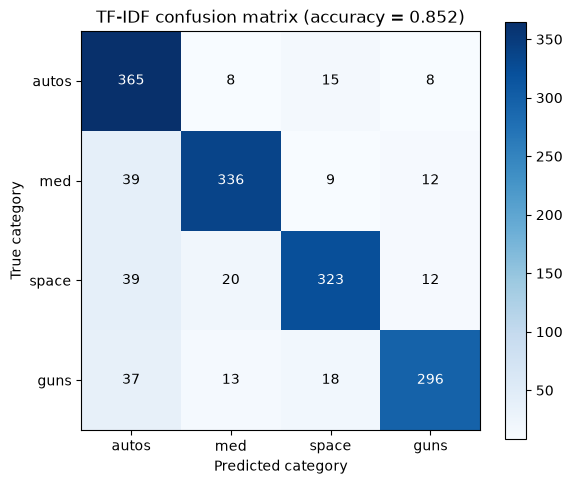

In [23]:
# Build a labeled heatmap confusion matrix for the TF-IDF baseline
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_tfidf = confusion_matrix(test.target, clf.predict(X_test_tfidf))
short_names = ['autos', 'med', 'space', 'guns']  # shortened for display

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_tfidf, cmap='Blues')
ax.set_xticks(range(4)); ax.set_xticklabels(short_names)
ax.set_yticks(range(4)); ax.set_yticklabels(short_names)
ax.set_xlabel('Predicted category'); ax.set_ylabel('True category')
ax.set_title(f'TF-IDF confusion matrix (accuracy = {acc:.3f})')
for i in range(4):
    for j in range(4):
        color = 'white' if cm_tfidf[i, j] > cm_tfidf.max() / 2 else 'black'
        ax.text(j, i, cm_tfidf[i, j], ha='center', va='center', color=color)
plt.colorbar(im); plt.tight_layout(); plt.show()

# Four-model confusion matrix comparison

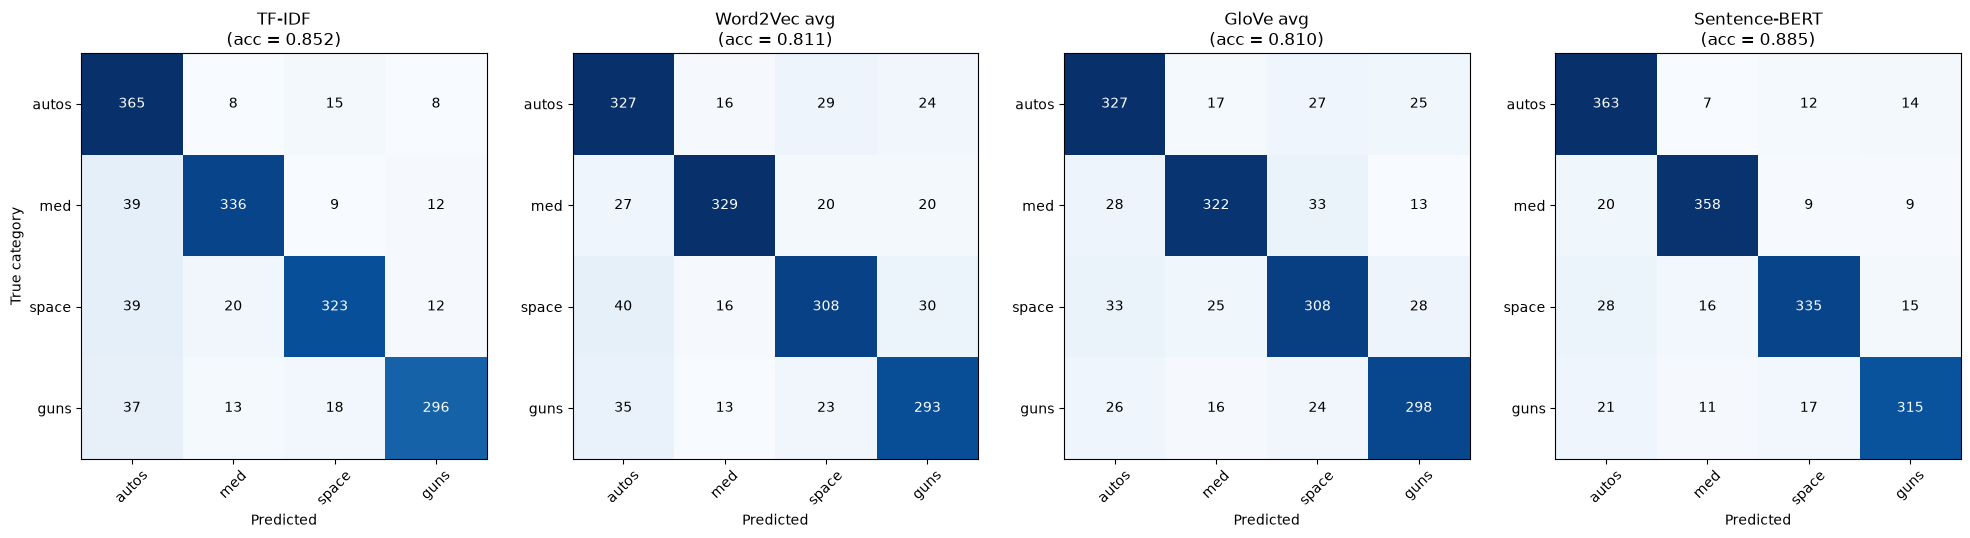

In [24]:
# Compare confusion matrices for all four models side by side
models = [('TF-IDF', clf, X_test_tfidf, acc),
          ('Word2Vec avg', clf_w2v, X_test_w2v, acc_w2v),
          ('GloVe avg', clf_glove, X_test_glove, acc_glove),
          ('Sentence-BERT', clf_sbert, X_test_sbert, acc_sbert)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, model, X, model_acc) in zip(axes, models):
    cm = confusion_matrix(test.target, model.predict(X))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(4)); ax.set_xticklabels(short_names, rotation=45)
    ax.set_yticks(range(4)); ax.set_yticklabels(short_names)
    ax.set_title(f'{name}\n(acc = {model_acc:.3f})')
    ax.set_xlabel('Predicted')
    for i in range(4):
        for j in range(4):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=10)
axes[0].set_ylabel('True category')
plt.tight_layout()
plt.show()

In [25]:
# Per-class precision, recall, F1 for each model
from sklearn.metrics import classification_report
import pandas as pd

results = {}
for name, model, X, _ in models:
    report = classification_report(test.target, model.predict(X),
                                    target_names=train.target_names,
                                    output_dict=True, zero_division=0)
    for cat in train.target_names:
        results.setdefault(cat, {})[name] = {
            'precision': report[cat]['precision'],
            'recall': report[cat]['recall'],
            'f1': report[cat]['f1-score'],
        }

# Display as a table per category
for cat in train.target_names:
    print(f"\n{cat}:")
    df = pd.DataFrame(results[cat]).T.round(3)
    print(df.to_string())


rec.autos:
               precision  recall     f1
TF-IDF             0.760   0.922  0.833
Word2Vec avg       0.762   0.826  0.793
GloVe avg          0.790   0.826  0.807
Sentence-BERT      0.840   0.917  0.877

sci.med:
               precision  recall     f1
TF-IDF             0.891   0.848  0.869
Word2Vec avg       0.880   0.831  0.855
GloVe avg          0.847   0.813  0.830
Sentence-BERT      0.913   0.904  0.909

sci.space:
               precision  recall     f1
TF-IDF             0.885   0.820  0.851
Word2Vec avg       0.811   0.782  0.796
GloVe avg          0.786   0.782  0.784
Sentence-BERT      0.898   0.850  0.874

talk.politics.guns:
               precision  recall     f1
TF-IDF             0.902   0.813  0.855
Word2Vec avg       0.798   0.805  0.802
GloVe avg          0.819   0.819  0.819
Sentence-BERT      0.892   0.865  0.879


# **Interactive prediction widget**

In [26]:
# Interactive text classifier: type a sentence, see how four models classify it
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_sk

EXAMPLES = [
    "I've been having chest pain for two weeks — should I see a cardiologist?",
    "The Hubble telescope just captured images of a new exoplanet.",
    "My 2015 Honda's engine is making a knocking sound after 90,000 miles.",
    "The Second Amendment protects individual gun ownership rights.",
    "NASA astronauts require regular medical checkups before spaceflight.",
]

def classify_and_show(text):
    if not text.strip():
        return
    # Get prediction + confidence from each model
    text_tfidf = tfidf.transform([text])
    text_w2v   = doc_to_avg_vec(text, w2v, 300).reshape(1, -1)
    text_glove = doc_to_avg_vec(text, glove, 100).reshape(1, -1)
    text_sbert = sbert.encode([text])
    predictions = [
        ('TF-IDF',        clf.predict(text_tfidf)[0],        clf.predict_proba(text_tfidf)[0].max()),
        ('Word2Vec avg',  clf_w2v.predict(text_w2v)[0],       clf_w2v.predict_proba(text_w2v)[0].max()),
        ('GloVe avg',     clf_glove.predict(text_glove)[0],   clf_glove.predict_proba(text_glove)[0].max()),
        ('Sentence-BERT', clf_sbert.predict(text_sbert)[0],   clf_sbert.predict_proba(text_sbert)[0].max()),
    ]
    with out:
        clear_output()
        print(f"Query: {text!r}\n")
        print(f"{'Model':<16} {'Predicted':<22} {'Confidence':>10}")
        print("-" * 52)
        for name, pred, conf in predictions:
            label = train.target_names[pred]
            marker = " ★" if conf > 0.7 else ""
            print(f"{name:<16} {label:<22} {conf:>10.3f}{marker}")
        # Find the most similar training document using SBERT
        sims = cos_sim_sk(text_sbert, X_train_sbert)[0]
        best_idx = sims.argmax()
        print(f"\nMost similar training document (SBERT similarity = {sims[best_idx]:.3f}):")
        print(f"[category: {train.target_names[train.target[best_idx]]}]")
        print(f"{train.data[best_idx][:250].strip()}...")

# Build the widget
inp = widgets.Textarea(placeholder="Type a sentence to classify...",
                        layout=widgets.Layout(width='100%', height='60px'))
btn = widgets.Button(description='Predict', button_style='primary', icon='play')
out = widgets.Output()
example_btns = [widgets.Button(description=f"Example {i+1}", layout=widgets.Layout(width='150px'))
                for i in range(len(EXAMPLES))]
def on_predict(_): classify_and_show(inp.value)
def make_example_handler(text):
    def handler(_): inp.value = text
    return handler
btn.on_click(on_predict)
for eb, ex in zip(example_btns, EXAMPLES): eb.on_click(make_example_handler(ex))

display(widgets.VBox([
    widgets.HTML("<b>Examples (click to fill the text box):</b>"),
    widgets.HBox(example_btns[:3]),
    widgets.HBox(example_btns[3:]),
    widgets.HTML("<br><b>Enter your own text:</b>"),
    inp, btn, out
]))

---

## 🎯 In-Lab Task — Investigate ambiguous predictions

Click Example 5 in the widget above and run **Predict**. Observe the output carefully.

The sentence — *"NASA astronauts require regular medical checkups before spaceflight."* — is deliberately ambiguous. It mentions:

- **NASA, astronauts, spaceflight** → space content
- **medical checkups** → medical content

There is no "correct" answer. A reasonable human might file it under either category. Each model must break the tie somehow, and how they break it reveals what each model actually "understands."

### Your task (10 marks)

**Part 1 — Observe (2 marks).**
Record which category each of the four models predicted for Example 5, and its confidence score. Present as a table.

**Part 2 — Explain each model's choice (4 marks).**
For each of the four models, explain in 1-2 sentences *why* you think it made that specific prediction. Reference what you know about how each model works:

- What did TF-IDF weight most heavily?
- What direction did the averaged Word2Vec / GloVe vectors point?
- What contextual reading did SBERT do that word-average methods couldn't?

**Part 3 — Design your own ambiguous test cases (4 marks).**
Write **three new sentences of your own** that are deliberately ambiguous between two of our four categories. For each:

- State the two categories it could belong to and why
- Run it through the widget
- Report which model handled the ambiguity best (or worst), in your judgment

Examples of ambiguity patterns to try:

- **rec.autos × talk.politics.guns**: "The government's new regulation on truck safety features..."
- **sci.med × talk.politics.guns**: something involving gunshot wound statistics
- **sci.med × rec.autos**: car accident injury statistics
- **sci.space × rec.autos**: fuel efficiency of rocket engines vs cars

Your sentences should be **plausible real sentences**, not intentionally weird. The goal is to test how well each model handles the *natural gray areas* of real-world text — the kind of ambiguity a deployed classifier will face daily.

### What you're really learning

In deployment, most user queries fall into one of three buckets:

- **Clearly in one category** (models will agree, high confidence — easy case)
- **Clearly not in the training categories** (all models will guess; low confidence — should trigger a "please rephrase" response)
- **Ambiguous, plausibly two categories** (models will disagree — this is where model choice really matters)

**Understanding your model's ambiguity behavior IS the deployment skill.** A model that confidently misclassifies 5% of ambiguous cases into the wrong category is a real risk. A model that returns low confidence and defers to a human is safer.

### Submit

Add your table, explanations, and three test cases as **markdown cells** immediately below this one. Save the notebook as `05_embeddings_YOURNAME.ipynb`.

**Deadline**: end of today's session.

---

## Phase 9 wrap-up — what testing revealed

We went beyond accuracy numbers into three diagnostic tools that every deployed classifier needs:

### 1. Confusion matrices exposed structural failures

The heatmaps revealed that **TF-IDF had a specific weakness**: everything leaked into `rec.autos`. That failure mode was invisible in the single accuracy number. Sentence-BERT reduced this leak by 40%, which is where most of its accuracy gain came from.

### 2. Per-class metrics exposed category-level tradeoffs

Every model had different strengths:
- **TF-IDF**: highest recall on autos (0.922), highest precision on guns (0.902)
- **SBERT**: highest F1 on every category, largest gain on sci.med (+4 points)
- **Word2Vec / GloVe**: consistently mid-tier, worst on sci.space where technical terms got averaged into general vectors

**Deployment insight**: model choice is not "which is best?" — it's "which is best for the class my product cares most about?"

### 3. Interactive testing exposed ambiguity behavior

Testing on ambiguous sentences (Example 5, plus your own three) revealed that different models disambiguate differently. TF-IDF prioritizes distinctive keywords; SBERT reads context. Neither is "correct" — they're different worldviews.

**Deployment insight**: in production, disagreement between models is a signal to route the query for human review rather than force a confident-but-wrong prediction.

---

## Lab 05 — Final synthesis

You have now built five classifiers on real-world text and evaluated them extensively. Here is the arc:

### The full comparison table

| Method | Accuracy | Δ vs TF-IDF | Speed (encoding) | Best-in-class |
|---|---|---|---|---|
| Averaged GloVe (2014) | 80.97% | −4.19 pp | Fast | — |
| Averaged Word2Vec (2013) | 81.10% | −4.06 pp | Fast | — |
| TF-IDF + LogReg (1972) | 85.16% | (baseline) | Very fast | autos recall, guns precision |
| **Sentence-BERT (2019)** | **88.45%** | **+3.29 pp** | Slow (CPU) | med F1, med recall, everywhere else |

### The four big lessons

**1. Always try TF-IDF first.** A 1972 technique beat two "modern" embedding methods on a real classification task. It's fast, interpretable, and hard to beat without genuinely more sophisticated approaches.

**2. Averaging word embeddings is a bottleneck.** Word2Vec and GloVe are both excellent models, but averaging their vectors destroys most of what makes them powerful. The specific pretrained model barely matters when you average — the operation itself is the limit.

**3. Sentence-level embeddings need sentence-level architecture.** SBERT beat TF-IDF because it was designed from the ground up for sentence representations — attention over words, context-aware, no averaging. This is the specific architectural improvement that made modern embeddings actually useful.

**4. Real evaluation goes beyond accuracy.** Confusion matrices, per-class metrics, and interactive testing revealed patterns that a single number can never show. In deployment, these diagnostics are what determine whether a model ships or gets sent back for improvement.

### What's next

You now have all the tools for classical and modern text classification. Two natural directions in future labs:

- **Lab 06 — Semantic search and retrieval-augmented generation (RAG)**: use SBERT vectors to build a real search engine that finds relevant documents for a query, then feeds them to your local Qwen model for grounded answering.
- **Lab 07 — Fine-tuning embeddings for a specific domain**: take a pretrained model and adapt it to a specialized vocabulary (medical, legal, scientific). Compare against off-the-shelf performance.

Both build directly on what you learned here.

---

*Lab 05 complete. Save your notebook as `05_embeddings_for_classification.ipynb` and push to GitHub.*